In [1]:
# ============================================================
# DSCD 614 — PPO-2
# Notebook 01: Environment & Synthetic Profile Validation
# ============================================================

from pathlib import Path
import sys
import os

from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# Search Google Drive for the existing project folder
DRIVE_ROOT = Path("/content/drive/MyDrive")

matches = list(DRIVE_ROOT.rglob("PPO-Building-Temperature-Control"))

if not matches:
    raise FileNotFoundError(
        "Could not find 'PPO-Building-Temperature-Control' in MyDrive. "
        "Check the folder name and location."
    )

PROJECT_ROOT = matches[0]

print("Project root:")
print(PROJECT_ROOT)

Project root:
/content/drive/MyDrive/PPO-Building-Temperature-Control


In [3]:
# Verify the directories we agreed on

required_dirs = [
    "config",
    "data",
    "environment",
    "baseline",
    "agent",
    "evaluation",
    "experiments",
    "notebooks",
    "models",
    "logs",
    "results",
    "figures",
]

missing_dirs = [
    d for d in required_dirs
    if not (PROJECT_ROOT / d).exists()
]

if missing_dirs:
    print("Missing directories:")
    for d in missing_dirs:
        print(f"  - {d}")
else:
    print("✓ Project structure verified.")

Missing directories:
  - data


In [4]:
# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from environment.profiles import (
    ProfileConfig,
    generate_daily_profile,
    generate_profiles,
    validate_profiles,
)

print("✓ Profile generator imported successfully.")

✓ Profile generator imported successfully.


In [5]:
# Initial profile configuration
profile_config = ProfileConfig()

print(profile_config)

ProfileConfig(episode_hours=24, base_outdoor_temp_c=27.0, outdoor_amplitude_c=4.5, outdoor_noise_std_c=0.6, comfort_setpoint_c=22.0, base_price=0.5, peak_price=1.0, price_noise_std=0.04, occupancy_noise_std=0.04)


In [6]:
# Generate one reproducible daily profile

single_profile = generate_daily_profile(
    seed=2026,
    config=profile_config,
    profile_id="validation_day_001",
)

single_profile

,profile_id,hour,outdoor_temp_c,occupancy,electricity_price,comfort_setpoint_c
0,validation_day_001,0,21.785035,0.001472,0.564737,22.0
1,validation_day_001,1,23.022222,0.083928,0.533084,22.0
2,validation_day_001,2,22.103764,0.000000,0.473447,22.0
3,validation_day_001,3,21.387306,0.036999,0.539779,22.0
4,validation_day_001,4,21.533617,0.000000,0.482292,22.0
5,validation_day_001,5,22.367060,0.084058,0.499134,22.0
6,validation_day_001,6,22.762235,0.063357,0.488383,22.0
7,validation_day_001,7,23.749161,0.295509,0.711353,22.0
8,validation_day_001,8,25.436874,0.564579,0.751523,22.0
9,validation_day_001,9,26.515701,0.827382,0.677777,22.0


In [7]:
# Structural checks

print("Number of rows:", len(single_profile))
print("Columns:")
print(single_profile.columns.tolist())

print("\nMissing values:")
print(single_profile.isna().sum())

print("\nHour values:")
print(single_profile["hour"].tolist())

Number of rows: 24
Columns:
['profile_id', 'hour', 'outdoor_temp_c', 'occupancy', 'electricity_price', 'comfort_setpoint_c']

Missing values:
profile_id            0
hour                  0
outdoor_temp_c        0
occupancy             0
electricity_price     0
comfort_setpoint_c    0
dtype: int64

Hour values:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [8]:
# Run the built-in validation

validation_result = validate_profiles(single_profile)

validation_result

{'no_missing_values': True,
 'hour_range_valid': np.True_,
 'occupancy_range_valid': np.True_,
 'price_nonnegative': np.True_,
 'one_day_per_profile': np.True_,
 'profile_count': 1,
 'row_count': 24,
 'all_checks_passed': False}

In [9]:
# Initial pilot profile quantities
TRAIN_DAYS = 500
VALIDATION_DAYS = 100
TEST_DAYS = 100

PROFILE_SEED = 2026

train_profiles = generate_profiles(
    n_profiles=TRAIN_DAYS,
    seed=PROFILE_SEED,
    split="train",
    config=profile_config,
)

validation_profiles = generate_profiles(
    n_profiles=VALIDATION_DAYS,
    seed=PROFILE_SEED + 1,
    split="validation",
    config=profile_config,
)

test_profiles = generate_profiles(
    n_profiles=TEST_DAYS,
    seed=PROFILE_SEED + 2,
    split="test",
    config=profile_config,
)

print("Train:", train_profiles.shape)
print("Validation:", validation_profiles.shape)
print("Test:", test_profiles.shape)

Train: (12000, 7)
Validation: (2400, 7)
Test: (2400, 7)


In [10]:
# Validate each split

for name, df in {
    "TRAIN": train_profiles,
    "VALIDATION": validation_profiles,
    "TEST": test_profiles,
}.items():

    result = validate_profiles(df)

    print(f"\n{name}")
    print("-" * 40)

    for key, value in result.items():
        print(f"{key}: {value}")


TRAIN
----------------------------------------
no_missing_values: True
hour_range_valid: True
occupancy_range_valid: True
price_nonnegative: True
one_day_per_profile: True
profile_count: 500
row_count: 12000
all_checks_passed: False

VALIDATION
----------------------------------------
no_missing_values: True
hour_range_valid: True
occupancy_range_valid: True
price_nonnegative: True
one_day_per_profile: True
profile_count: 100
row_count: 2400
all_checks_passed: False

TEST
----------------------------------------
no_missing_values: True
hour_range_valid: True
occupancy_range_valid: True
price_nonnegative: True
one_day_per_profile: True
profile_count: 100
row_count: 2400
all_checks_passed: False


In [11]:
# Verify profile IDs do not overlap

train_ids = set(train_profiles["profile_id"])
validation_ids = set(validation_profiles["profile_id"])
test_ids = set(test_profiles["profile_id"])

print("Train ∩ Validation:", len(train_ids & validation_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(validation_ids & test_ids))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


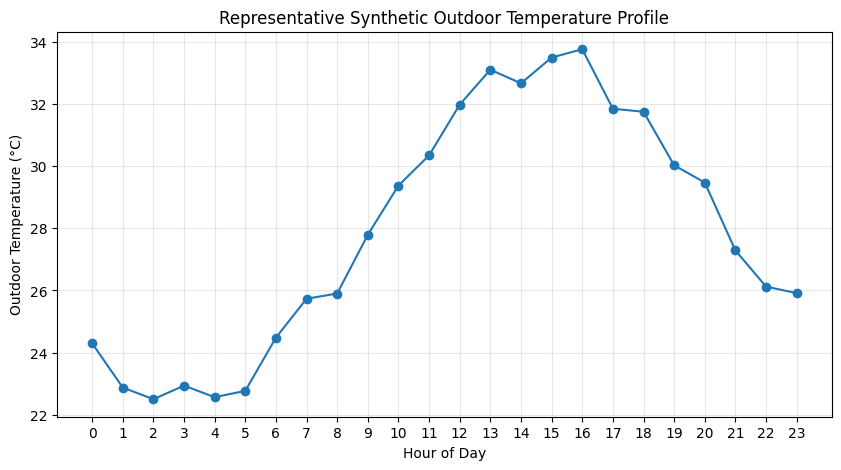

In [12]:
import matplotlib.pyplot as plt

day = train_profiles[
    train_profiles["profile_id"] == train_profiles["profile_id"].iloc[0]
]

plt.figure(figsize=(10, 5))

plt.plot(
    day["hour"],
    day["outdoor_temp_c"],
    marker="o",
)

plt.xlabel("Hour of Day")
plt.ylabel("Outdoor Temperature (°C)")
plt.title("Representative Synthetic Outdoor Temperature Profile")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

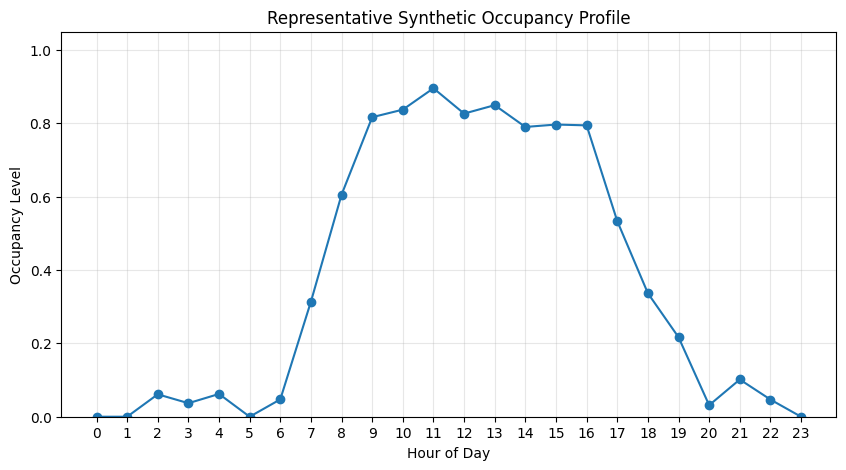

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    day["hour"],
    day["occupancy"],
    marker="o",
)

plt.xlabel("Hour of Day")
plt.ylabel("Occupancy Level")
plt.title("Representative Synthetic Occupancy Profile")
plt.xticks(range(24))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.show()

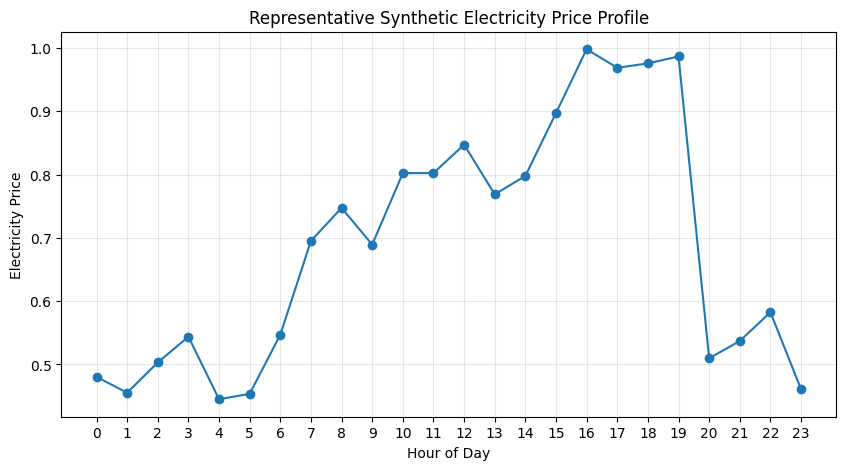

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    day["hour"],
    day["electricity_price"],
    marker="o",
)

plt.xlabel("Hour of Day")
plt.ylabel("Electricity Price")
plt.title("Representative Synthetic Electricity Price Profile")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

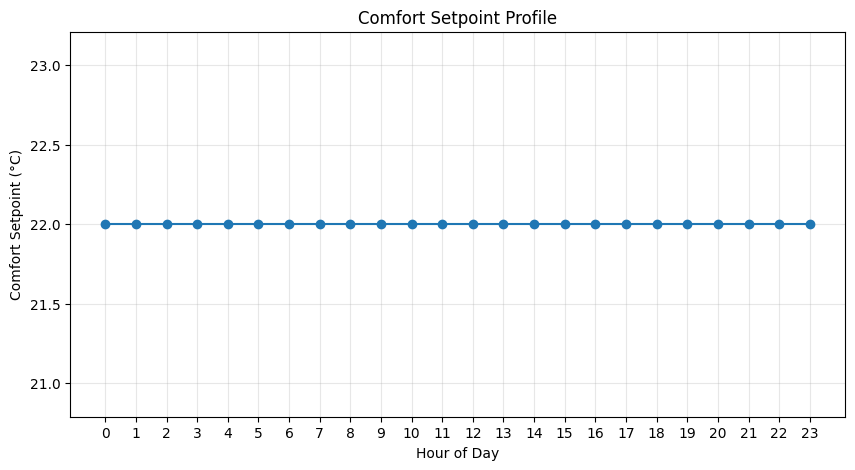

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    day["hour"],
    day["comfort_setpoint_c"],
    marker="o",
)

plt.xlabel("Hour of Day")
plt.ylabel("Comfort Setpoint (°C)")
plt.title("Comfort Setpoint Profile")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [16]:
# Reproducibility tes
profile_a = generate_daily_profile(
    seed=999,
    config=profile_config,
    profile_id="test_a",
)

profile_b = generate_daily_profile(
    seed=999,
    config=profile_config,
    profile_id="test_b",
)

# Ignore profile_id because we intentionally gave them different IDs
comparison_columns = [
    "hour",
    "outdoor_temp_c",
    "occupancy",
    "electricity_price",
    "comfort_setpoint_c",
]

same_values = profile_a[comparison_columns].equals(
    profile_b[comparison_columns]
)

print("Same seed produces identical values:", same_values)

Same seed produces identical values: True


In [17]:
# Different seed tes
profile_c = generate_daily_profile(
    seed=1000,
    config=profile_config,
    profile_id="test_c",
)

different_values = not profile_a[comparison_columns].equals(
    profile_c[comparison_columns]
)

print("Different seeds produce different profiles:", different_values)

Different seeds produce different profiles: True


In [18]:
# Save the plots
validation_output_dir = PROJECT_ROOT / "data" / "profiles"

validation_output_dir.mkdir(parents=True, exist_ok=True)

single_profile.to_csv(
    validation_output_dir / "validation_day_001.csv",
    index=False,
)

print(
    "Saved:",
    validation_output_dir / "validation_day_001.csv"
)

Saved: /content/drive/MyDrive/PPO-Building-Temperature-Control/data/profiles/validation_day_001.csv


In [19]:
# ============================================================
# Phase 6C — Create thermal_model.py
# ============================================================

from pathlib import Path

thermal_model_code = r'''
"""Physics-inspired single-zone building thermal model."""

from __future__ import annotations

from dataclasses import dataclass


@dataclass(frozen=True)
class ThermalConfig:
    """Parameters governing single-zone indoor temperature dynamics."""

    outdoor_coupling: float = 0.08
    hvac_effect_c_per_action: float = 3.0
    occupancy_heat_gain_c: float = 0.15
    disturbance_std_c: float = 0.0


class ThermalModel:
    """Simple physics-inspired building thermal model.

    Positive action = heating.
    Negative action = cooling.
    """

    def __init__(
        self,
        config: ThermalConfig | None = None,
        rng=None,
    ):
        self.config = config or ThermalConfig()
        self.rng = rng

    def next_temperature(
        self,
        indoor_temp_c: float,
        outdoor_temp_c: float,
        occupancy: float,
        action: float,
    ) -> float:
        """Calculate the next indoor temperature."""

        if not -1.0 <= action <= 1.0:
            raise ValueError("HVAC action must be in [-1, 1].")

        if not 0.0 <= occupancy <= 1.0:
            raise ValueError("Occupancy must be in [0, 1].")

        cfg = self.config

        outdoor_effect = (
            cfg.outdoor_coupling
            * (outdoor_temp_c - indoor_temp_c)
        )

        hvac_effect = (
            cfg.hvac_effect_c_per_action
            * action
        )

        occupancy_effect = (
            cfg.occupancy_heat_gain_c
            * occupancy
        )

        disturbance = 0.0

        if cfg.disturbance_std_c > 0:
            if self.rng is None:
                raise ValueError(
                    "An RNG is required when disturbance_std_c > 0."
                )

            disturbance = self.rng.normal(
                0.0,
                cfg.disturbance_std_c,
            )

        next_temp = (
            indoor_temp_c
            + outdoor_effect
            + hvac_effect
            + occupancy_effect
            + disturbance
        )

        return float(next_temp)
'''

thermal_path = PROJECT_ROOT / "environment" / "thermal_model.py"
thermal_path.write_text(thermal_model_code.strip() + "\n", encoding="utf-8")

print(f"Created: {thermal_path}")

Created: /content/drive/MyDrive/PPO-Building-Temperature-Control/environment/thermal_model.py


In [20]:
# ============================================================
# Import and configure thermal model
# ============================================================

from environment.thermal_model import ThermalConfig, ThermalModel

thermal_config = ThermalConfig()

thermal_model = ThermalModel(
    config=thermal_config
)

print(thermal_config)

ThermalConfig(outdoor_coupling=0.08, hvac_effect_c_per_action=3.0, occupancy_heat_gain_c=0.15, disturbance_std_c=0.0)


In [21]:
# ============================================================
# Test 1 — No HVAC
# ============================================================

indoor = 22.0
outdoor = 32.0
occupancy = 0.0
action = 0.0

next_indoor = thermal_model.next_temperature(
    indoor_temp_c=indoor,
    outdoor_temp_c=outdoor,
    occupancy=occupancy,
    action=action,
)

print(f"Current indoor temperature: {indoor:.2f} °C")
print(f"Outdoor temperature:        {outdoor:.2f} °C")
print(f"HVAC action:                {action:.2f}")
print(f"Next indoor temperature:    {next_indoor:.2f} °C")

Current indoor temperature: 22.00 °C
Outdoor temperature:        32.00 °C
HVAC action:                0.00
Next indoor temperature:    22.80 °C


In [22]:
# ============================================================
# Test 2 — Maximum heating
# ============================================================

next_heating = thermal_model.next_temperature(
    indoor_temp_c=22.0,
    outdoor_temp_c=25.0,
    occupancy=0.0,
    action=1.0,
)

print(f"Next temperature with maximum heating: {next_heating:.2f} °C")

Next temperature with maximum heating: 25.24 °C


In [23]:
# ============================================================
# Test 3 — Maximum cooling
# ============================================================

next_cooling = thermal_model.next_temperature(
    indoor_temp_c=22.0,
    outdoor_temp_c=30.0,
    occupancy=0.0,
    action=-1.0,
)

print(f"Next temperature with maximum cooling: {next_cooling:.2f} °C")

Next temperature with maximum cooling: 19.64 °C


In [24]:
# ============================================================
# Test 4 — Occupancy effect
# ============================================================

no_occupancy = thermal_model.next_temperature(
    indoor_temp_c=22.0,
    outdoor_temp_c=22.0,
    occupancy=0.0,
    action=0.0,
)

full_occupancy = thermal_model.next_temperature(
    indoor_temp_c=22.0,
    outdoor_temp_c=22.0,
    occupancy=1.0,
    action=0.0,
)

print(f"No occupancy:   {no_occupancy:.2f} °C")
print(f"Full occupancy: {full_occupancy:.2f} °C")

No occupancy:   22.00 °C
Full occupancy: 22.15 °C


In [25]:
# ============================================================
# Test 5 — Heating vs cooling direction
# ============================================================

base = thermal_model.next_temperature(
    indoor_temp_c=22.0,
    outdoor_temp_c=28.0,
    occupancy=0.0,
    action=0.0,
)

heating = thermal_model.next_temperature(
    indoor_temp_c=22.0,
    outdoor_temp_c=28.0,
    occupancy=0.0,
    action=1.0,
)

cooling = thermal_model.next_temperature(
    indoor_temp_c=22.0,
    outdoor_temp_c=28.0,
    occupancy=0.0,
    action=-1.0,
)

assert heating > base
assert cooling < base

print("✓ Heating raises temperature relative to no HVAC.")
print("✓ Cooling lowers temperature relative to no HVAC.")

✓ Heating raises temperature relative to no HVAC.
✓ Cooling lowers temperature relative to no HVAC.


In [26]:
# ============================================================
# Test 6 — Action bounds
# ============================================================

for invalid_action in [-1.1, 1.1, -2.0, 2.0]:

    try:
        thermal_model.next_temperature(
            indoor_temp_c=22.0,
            outdoor_temp_c=28.0,
            occupancy=0.5,
            action=invalid_action,
        )

    except ValueError:
        continue

    raise AssertionError(
        f"Invalid action {invalid_action} was not rejected."
    )

print("✓ Invalid HVAC actions are rejected.")

✓ Invalid HVAC actions are rejected.


In [27]:
# ============================================================
# Test 7 — 24-hour passive trajectory
# ============================================================

day = train_profiles[
    train_profiles["profile_id"] == train_profiles["profile_id"].iloc[0]
].copy()

indoor_temperature = 22.0
trajectory = []

for _, row in day.iterrows():

    trajectory.append(indoor_temperature)

    indoor_temperature = thermal_model.next_temperature(
        indoor_temp_c=indoor_temperature,
        outdoor_temp_c=row["outdoor_temp_c"],
        occupancy=row["occupancy"],
        action=0.0,
    )

day["indoor_temp_c"] = trajectory

day[[
    "hour",
    "outdoor_temp_c",
    "occupancy",
    "indoor_temp_c",
]].head(24)

,hour,outdoor_temp_c,occupancy,indoor_temp_c
0,0,24.298415,0.000000,22.000000
1,1,22.874378,0.000000,22.183873
2,2,22.498292,0.061158,22.239114
3,3,22.936245,0.036874,22.269022
4,4,22.564013,0.062098,22.327931
5,5,22.767814,0.000000,22.356132
6,6,24.479641,0.047316,22.389066
7,7,25.732426,0.313898,22.563410
8,8,25.900876,0.605662,22.864016
9,9,27.791677,0.816894,23.197814


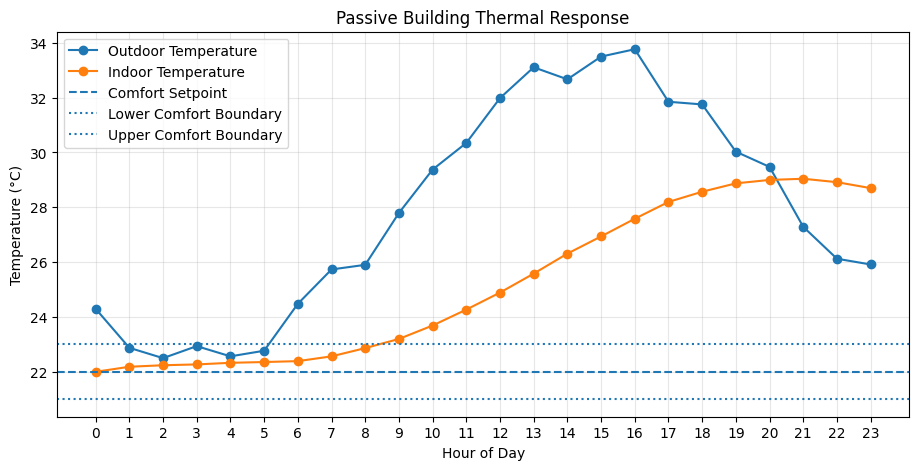

In [28]:
# ============================================================
# Thermal response visualization
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    day["hour"],
    day["outdoor_temp_c"],
    marker="o",
    label="Outdoor Temperature",
)

plt.plot(
    day["hour"],
    day["indoor_temp_c"],
    marker="o",
    label="Indoor Temperature",
)

plt.axhline(
    22.0,
    linestyle="--",
    label="Comfort Setpoint",
)

plt.axhline(
    21.0,
    linestyle=":",
    label="Lower Comfort Boundary",
)

plt.axhline(
    23.0,
    linestyle=":",
    label="Upper Comfort Boundary",
)

plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.title("Passive Building Thermal Response")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [29]:
# ============================================================
# Phase 6D — Create reward.py
# ============================================================

reward_code = r'''
"""Reward function for PPO-2 building temperature control."""

from __future__ import annotations

from dataclasses import dataclass


@dataclass(frozen=True)
class RewardConfig:
    """Configuration for the energy-comfort reward."""

    energy_weight: float = 0.30
    cost_weight: float = 0.20
    comfort_weight: float = 0.40
    violation_weight: float = 1.00

    comfort_tolerance_c: float = 1.0

    # Broad safety limits used to identify severe temperature conditions.
    lower_temperature_limit_c: float = 18.0
    upper_temperature_limit_c: float = 26.0

    # Reference scales used for normalization.
    max_energy: float = 1.0
    max_price: float = 1.0


class RewardCalculator:
    """Calculate energy-efficiency and thermal-comfort rewards."""

    def __init__(self, config: RewardConfig | None = None):
        self.config = config or RewardConfig()

    def calculate(
        self,
        indoor_temp_c: float,
        setpoint_c: float,
        action: float,
        electricity_price: float,
    ) -> dict:
        """Calculate reward and its individual components."""

        cfg = self.config

        if not -1.0 <= action <= 1.0:
            raise ValueError("HVAC action must be in [-1, 1].")

        if electricity_price < 0:
            raise ValueError("Electricity price must be non-negative.")

        # --------------------------------------------------------
        # 1. HVAC energy
        # --------------------------------------------------------
        energy = abs(action) * cfg.max_energy

        normalized_energy = (
            energy / cfg.max_energy
            if cfg.max_energy > 0
            else 0.0
        )

        # --------------------------------------------------------
        # 2. Electricity cost
        # --------------------------------------------------------
        cost = electricity_price * energy

        max_reference_cost = cfg.max_price * cfg.max_energy

        normalized_cost = (
            cost / max_reference_cost
            if max_reference_cost > 0
            else 0.0
        )

        # --------------------------------------------------------
        # 3. Comfort deviation
        # --------------------------------------------------------
        deviation = abs(indoor_temp_c - setpoint_c)

        discomfort = max(
            0.0,
            deviation - cfg.comfort_tolerance_c,
        )

        # --------------------------------------------------------
        # 4. Severe temperature violation
        # --------------------------------------------------------
        violation = float(
            indoor_temp_c < cfg.lower_temperature_limit_c
            or indoor_temp_c > cfg.upper_temperature_limit_c
        )

        # --------------------------------------------------------
        # 5. Reward components
        # --------------------------------------------------------
        energy_penalty = (
            cfg.energy_weight * normalized_energy
        )

        cost_penalty = (
            cfg.cost_weight * normalized_cost
        )

        comfort_penalty = (
            cfg.comfort_weight * discomfort
        )

        violation_penalty = (
            cfg.violation_weight * violation
        )

        reward = -(
            energy_penalty
            + cost_penalty
            + comfort_penalty
            + violation_penalty
        )

        return {
            "reward": float(reward),
            "energy": float(energy),
            "electricity_cost": float(cost),
            "comfort_deviation": float(deviation),
            "discomfort": float(discomfort),
            "temperature_violation": bool(violation),
            "energy_penalty": float(energy_penalty),
            "cost_penalty": float(cost_penalty),
            "comfort_penalty": float(comfort_penalty),
            "violation_penalty": float(violation_penalty),
        }
'''

reward_path = PROJECT_ROOT / "environment" / "reward.py"

reward_path.write_text(
    reward_code.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {reward_path}")

Created: /content/drive/MyDrive/PPO-Building-Temperature-Control/environment/reward.py


In [30]:
# ============================================================
# Import reward module
# ============================================================

from environment.reward import RewardConfig, RewardCalculator

reward_config = RewardConfig()

reward_calculator = RewardCalculator(
    config=reward_config
)

print(reward_config)

RewardConfig(energy_weight=0.3, cost_weight=0.2, comfort_weight=0.4, violation_weight=1.0, comfort_tolerance_c=1.0, lower_temperature_limit_c=18.0, upper_temperature_limit_c=26.0, max_energy=1.0, max_price=1.0)


In [31]:
# ============================================================
# Reward Test 1 — Comfortable + HVAC OFF
# ============================================================

result = reward_calculator.calculate(
    indoor_temp_c=22.0,
    setpoint_c=22.0,
    action=0.0,
    electricity_price=1.0,
)

print(result)

{'reward': -0.0, 'energy': 0.0, 'electricity_cost': 0.0, 'comfort_deviation': 0.0, 'discomfort': 0.0, 'temperature_violation': False, 'energy_penalty': 0.0, 'cost_penalty': 0.0, 'comfort_penalty': 0.0, 'violation_penalty': 0.0}


In [32]:
# ============================================================
# Reward Test 2 — HVAC consumption
# ============================================================

no_hvac = reward_calculator.calculate(
    indoor_temp_c=22.0,
    setpoint_c=22.0,
    action=0.0,
    electricity_price=1.0,
)

hvac = reward_calculator.calculate(
    indoor_temp_c=22.0,
    setpoint_c=22.0,
    action=0.5,
    electricity_price=1.0,
)

print("No HVAC reward:", no_hvac["reward"])
print("HVAC reward:   ", hvac["reward"])
print("Energy:        ", hvac["energy"])
print("Cost:          ", hvac["electricity_cost"])

assert hvac["energy"] > no_hvac["energy"]
assert hvac["reward"] < no_hvac["reward"]

print("\n✓ Unnecessary HVAC consumption is penalized.")

No HVAC reward: -0.0
HVAC reward:    -0.25
Energy:         0.5
Cost:           0.5

✓ Unnecessary HVAC consumption is penalized.


In [33]:
# ============================================================
# Reward Test 3 — Electricity price sensitivity
# ============================================================

low_price = reward_calculator.calculate(
    indoor_temp_c=22.0,
    setpoint_c=22.0,
    action=0.5,
    electricity_price=0.50,
)

high_price = reward_calculator.calculate(
    indoor_temp_c=22.0,
    setpoint_c=22.0,
    action=0.5,
    electricity_price=1.00,
)

print("Low-price reward: ", low_price["reward"])
print("High-price reward:", high_price["reward"])

assert high_price["electricity_cost"] > low_price["electricity_cost"]
assert high_price["reward"] < low_price["reward"]

print("\n✓ Higher electricity prices produce stronger cost penalties.")

Low-price reward:  -0.2
High-price reward: -0.25

✓ Higher electricity prices produce stronger cost penalties.


In [34]:
# ============================================================
# Reward Test 4 — Occupant discomfort
# ============================================================

comfortable = reward_calculator.calculate(
    indoor_temp_c=22.0,
    setpoint_c=22.0,
    action=0.0,
    electricity_price=0.5,
)

uncomfortable = reward_calculator.calculate(
    indoor_temp_c=24.0,
    setpoint_c=22.0,
    action=0.0,
    electricity_price=0.5,
)

print("Comfortable reward:   ", comfortable["reward"])
print("Uncomfortable reward:", uncomfortable["reward"])
print("Discomfort:           ", uncomfortable["discomfort"])

assert uncomfortable["discomfort"] > 0
assert uncomfortable["reward"] < comfortable["reward"]

print("\n✓ Temperature discomfort is penalized.")

Comfortable reward:    -0.0
Uncomfortable reward: -0.4
Discomfort:            1.0

✓ Temperature discomfort is penalized.


In [35]:
# ============================================================
# Reward Test 5 — Severe temperature violation
# ============================================================

normal = reward_calculator.calculate(
    indoor_temp_c=22.0,
    setpoint_c=22.0,
    action=0.0,
    electricity_price=0.5,
)

severe = reward_calculator.calculate(
    indoor_temp_c=28.0,
    setpoint_c=22.0,
    action=0.0,
    electricity_price=0.5,
)

print("Normal reward: ", normal["reward"])
print("Severe reward:", severe["reward"])
print("Violation:     ", severe["temperature_violation"])

assert severe["temperature_violation"] is True
assert severe["reward"] < normal["reward"]

print("\n✓ Severe temperature conditions receive a violation penalty.")

Normal reward:  -0.0
Severe reward: -3.0
Violation:      True

✓ Severe temperature conditions receive a violation penalty.


In [36]:
# ============================================================
# Reward decomposition
# ============================================================

scenario = reward_calculator.calculate(
    indoor_temp_c=24.5,
    setpoint_c=22.0,
    action=0.5,
    electricity_price=1.0,
)

for key, value in scenario.items():
    print(f"{key:25s}: {value}")

reward                   : -0.8500000000000001
energy                   : 0.5
electricity_cost         : 0.5
comfort_deviation        : 2.5
discomfort               : 1.5
temperature_violation    : False
energy_penalty           : 0.15
cost_penalty             : 0.1
comfort_penalty          : 0.6000000000000001
violation_penalty        : 0.0


In [37]:
# ============================================================
# Reward ordering sanity test
# ============================================================

scenarios = {
    "ideal": reward_calculator.calculate(
        indoor_temp_c=22.0,
        setpoint_c=22.0,
        action=0.0,
        electricity_price=0.5,
    ),

    "energy_use": reward_calculator.calculate(
        indoor_temp_c=22.0,
        setpoint_c=22.0,
        action=0.5,
        electricity_price=0.5,
    ),

    "discomfort": reward_calculator.calculate(
        indoor_temp_c=24.0,
        setpoint_c=22.0,
        action=0.0,
        electricity_price=0.5,
    ),

    "severe_violation": reward_calculator.calculate(
        indoor_temp_c=28.0,
        setpoint_c=22.0,
        action=0.0,
        electricity_price=0.5,
    ),
}

for name, result in scenarios.items():
    print(f"{name:20s}: {result['reward']:.4f}")

ideal               : -0.0000
energy_use          : -0.2000
discomfort          : -0.4000
severe_violation    : -3.0000


In [38]:
# ============================================================
# Phase 6E — Create building_env.py
# ============================================================

building_env_code = r'''
"""Gymnasium environment for energy-efficient building temperature control."""

from __future__ import annotations

import numpy as np
import gymnasium as gym
from gymnasium import spaces

from .thermal_model import ThermalConfig, ThermalModel
from .reward import RewardConfig, RewardCalculator


class BuildingTemperatureEnv(gym.Env):
    """Single-zone building temperature-control environment.

    Action:
        Continuous HVAC control in [-1, 1].
        Negative = cooling.
        Zero = HVAC off.
        Positive = heating.

    Observation:
        [indoor_temperature,
         outdoor_temperature,
         comfort_setpoint,
         electricity_price,
         occupancy,
         hour_sin,
         hour_cos]
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        profiles,
        thermal_config: ThermalConfig | None = None,
        reward_config: RewardConfig | None = None,
        initial_indoor_temp_c: float = 22.0,
    ):
        super().__init__()

        required_columns = {
            "profile_id",
            "hour",
            "outdoor_temp_c",
            "occupancy",
            "electricity_price",
            "comfort_setpoint_c",
        }

        missing = required_columns - set(profiles.columns)

        if missing:
            raise ValueError(
                f"Profiles are missing required columns: {sorted(missing)}"
            )

        self.profiles = profiles.copy()

        # Validate that every profile represents one 24-hour episode.
        profile_lengths = self.profiles.groupby("profile_id").size()

        if not (profile_lengths == 24).all():
            raise ValueError(
                "Every building profile must contain exactly 24 hourly steps."
            )

        self.profile_ids = self.profiles["profile_id"].unique().tolist()

        self.thermal_model = ThermalModel(
            config=thermal_config or ThermalConfig()
        )

        self.reward_calculator = RewardCalculator(
            config=reward_config or RewardConfig()
        )

        self.initial_indoor_temp_c = float(initial_indoor_temp_c)

        # --------------------------------------------------------
        # Continuous HVAC action
        # --------------------------------------------------------
        self.action_space = spaces.Box(
            low=np.array([-1.0], dtype=np.float32),
            high=np.array([1.0], dtype=np.float32),
            dtype=np.float32,
        )

        # --------------------------------------------------------
        # Normalized observation
        #
        # Temperature values are scaled by 40.
        # Price is scaled by 1.
        # Occupancy already lies in [0, 1].
        # Cyclic time features lie in [-1, 1].
        # --------------------------------------------------------
        self.observation_space = spaces.Box(
            low=np.array(
                [-np.inf, -np.inf, -np.inf, 0.0, 0.0, -1.0, -1.0],
                dtype=np.float32,
            ),
            high=np.array(
                [np.inf, np.inf, np.inf, 2.0, 1.0, 1.0, 1.0],
                dtype=np.float32,
            ),
            dtype=np.float32,
        )

        self.current_profile = None
        self.current_profile_id = None
        self.current_step = 0
        self.indoor_temp_c = self.initial_indoor_temp_c

    def _get_observation(self) -> np.ndarray:
        """Construct the current normalized observation."""

        row = self.current_profile.iloc[self.current_step]

        hour = float(row["hour"])

        hour_sin = np.sin(2.0 * np.pi * hour / 24.0)
        hour_cos = np.cos(2.0 * np.pi * hour / 24.0)

        observation = np.array(
            [
                self.indoor_temp_c / 40.0,
                float(row["outdoor_temp_c"]) / 40.0,
                float(row["comfort_setpoint_c"]) / 40.0,
                float(row["electricity_price"]),
                float(row["occupancy"]),
                hour_sin,
                hour_cos,
            ],
            dtype=np.float32,
        )

        return observation

    def reset(self, *, seed=None, options=None):
        """Reset the environment to the beginning of a daily profile."""

        super().reset(seed=seed)

        if options is not None and "profile_id" in options:
            requested_id = options["profile_id"]

            if requested_id not in self.profile_ids:
                raise ValueError(
                    f"Unknown profile_id: {requested_id}"
                )

            profile_id = requested_id

        else:
            # Reproducible profile selection when seed is supplied.
            index = self.np_random.integers(
                0,
                len(self.profile_ids),
            )
            profile_id = self.profile_ids[index]

        self.current_profile_id = profile_id

        self.current_profile = (
            self.profiles[
                self.profiles["profile_id"] == profile_id
            ]
            .sort_values("hour")
            .reset_index(drop=True)
        )

        self.current_step = 0
        self.indoor_temp_c = self.initial_indoor_temp_c

        observation = self._get_observation()

        info = {
            "profile_id": self.current_profile_id,
            "hour": int(self.current_profile.iloc[0]["hour"]),
            "indoor_temperature_c": self.indoor_temp_c,
        }

        return observation, info

    def step(self, action):
        """Apply HVAC action and advance the building simulation."""

        action = np.asarray(action, dtype=np.float32).reshape(-1)

        if action.size != 1:
            raise ValueError("Action must contain exactly one value.")

        action_value = float(action[0])

        # Protect against tiny floating-point excursions.
        action_value = float(np.clip(action_value, -1.0, 1.0))

        row = self.current_profile.iloc[self.current_step]

        outdoor_temp = float(row["outdoor_temp_c"])
        occupancy = float(row["occupancy"])
        electricity_price = float(row["electricity_price"])
        setpoint = float(row["comfort_setpoint_c"])

        previous_indoor_temp = self.indoor_temp_c

        # --------------------------------------------------------
        # Thermal transition
        # --------------------------------------------------------
        self.indoor_temp_c = self.thermal_model.next_temperature(
            indoor_temp_c=self.indoor_temp_c,
            outdoor_temp_c=outdoor_temp,
            occupancy=occupancy,
            action=action_value,
        )

        # --------------------------------------------------------
        # Reward
        # --------------------------------------------------------
        reward_info = self.reward_calculator.calculate(
            indoor_temp_c=self.indoor_temp_c,
            setpoint_c=setpoint,
            action=action_value,
            electricity_price=electricity_price,
        )

        reward = reward_info["reward"]

        # Move to the next hourly state.
        self.current_step += 1

        terminated = False
        truncated = self.current_step >= 24

        # At the end of the 24-hour episode, keep the final
        # observation associated with the last profile row.
        if truncated:
            self.current_step = 23

        observation = self._get_observation()

        info = {
            "profile_id": self.current_profile_id,
            "hour": int(row["hour"]),
            "previous_indoor_temperature_c": previous_indoor_temp,
            "indoor_temperature_c": self.indoor_temp_c,
            "outdoor_temperature_c": outdoor_temp,
            "comfort_setpoint_c": setpoint,
            "occupancy": occupancy,
            "electricity_price": electricity_price,
            "action": action_value,
            "energy": reward_info["energy"],
            "electricity_cost": reward_info["electricity_cost"],
            "comfort_deviation": reward_info["comfort_deviation"],
            "discomfort": reward_info["discomfort"],
            "temperature_violation": reward_info["temperature_violation"],
            "energy_penalty": reward_info["energy_penalty"],
            "cost_penalty": reward_info["cost_penalty"],
            "comfort_penalty": reward_info["comfort_penalty"],
            "violation_penalty": reward_info["violation_penalty"],
        }

        return (
            observation,
            float(reward),
            terminated,
            truncated,
            info,
        )
'''

env_path = PROJECT_ROOT / "environment" / "building_env.py"

env_path.write_text(
    building_env_code.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {env_path}")

Created: /content/drive/MyDrive/PPO-Building-Temperature-Control/environment/building_env.py


In [39]:
# ============================================================
# Import building environment
# ============================================================

from environment.building_env import BuildingTemperatureEnv

print("✓ BuildingTemperatureEnv imported successfully.")

✓ BuildingTemperatureEnv imported successfully.


In [40]:
# ============================================================
# Create validation environment
# ============================================================

validation_env = BuildingTemperatureEnv(
    profiles=train_profiles.head(72).copy(),
    thermal_config=thermal_config,
    reward_config=reward_config,
    initial_indoor_temp_c=22.0,
)

print("✓ Environment created.")

✓ Environment created.


In [41]:
# ============================================================
# Check Gymnasium spaces
# ============================================================

print("Action space:")
print(validation_env.action_space)

print("\nObservation space:")
print(validation_env.observation_space)

print("\nObservation shape:")
print(validation_env.observation_space.shape)

print("\nAction shape:")
print(validation_env.action_space.shape)

Action space:
Box(-1.0, 1.0, (1,), float32)

Observation space:
Box([-inf -inf -inf   0.   0.  -1.  -1.], [inf inf inf  2.  1.  1.  1.], (7,), float32)

Observation shape:
(7,)

Action shape:
(1,)


In [44]:
import numpy as np
# ============================================================
# Environment Test 1 — reset()
# ============================================================

observation, info = validation_env.reset(
    seed=42
)

print("Observation:")
print(observation)

print("\nObservation shape:")
print(observation.shape)

print("\nInfo:")
print(info)

assert observation.shape == (7,)
assert np.isfinite(observation).all()

print("\n✓ reset() returned a valid 7-dimensional observation.")

Observation:
[0.55       0.6074604  0.55       0.48040184 0.         0.
 1.        ]

Observation shape:
(7,)

Info:
{'profile_id': 'train_day_0001', 'hour': 0, 'indoor_temperature_c': 22.0}

✓ reset() returned a valid 7-dimensional observation.


In [45]:
# ============================================================
# Inspect state variables
# ============================================================

state_names = [
    "indoor_temperature",
    "outdoor_temperature",
    "comfort_setpoint",
    "electricity_price",
    "occupancy",
    "hour_sin",
    "hour_cos",
]

for name, value in zip(state_names, observation):
    print(f"{name:25s}: {value:.4f}")

indoor_temperature       : 0.5500
outdoor_temperature      : 0.6075
comfort_setpoint         : 0.5500
electricity_price        : 0.4804
occupancy                : 0.0000
hour_sin                 : 0.0000
hour_cos                 : 1.0000


In [46]:
# ============================================================
# Environment Test 2 — one step
# ============================================================

action = np.array([0.0], dtype=np.float32)

next_observation, reward, terminated, truncated, info = (
    validation_env.step(action)
)

print("Next observation:", next_observation)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

print("\nSelected info:")
print("Indoor temperature:", info["indoor_temperature_c"])
print("Energy:", info["energy"])
print("Electricity cost:", info["electricity_cost"])
print("Comfort deviation:", info["comfort_deviation"])

Next observation: [0.55459684 0.5718595  0.55       0.45525873 0.         0.25881904
 0.9659258 ]
Reward: -0.0
Terminated: False
Truncated: False

Selected info:
Indoor temperature: 22.18387318332753
Energy: 0.0
Electricity cost: 0.0
Comfort deviation: 0.1838731833275311


In [47]:
# ============================================================
# Environment Test 3 — Gymnasium API
# ============================================================

assert isinstance(next_observation, np.ndarray)
assert next_observation.shape == (7,)
assert isinstance(reward, (float, np.floating))
assert isinstance(terminated, bool)
assert isinstance(truncated, bool)
assert isinstance(info, dict)

assert np.isfinite(next_observation).all()
assert np.isfinite(reward)

print("✓ Gymnasium step() API validated.")

✓ Gymnasium step() API validated.


In [48]:
# ============================================================
# Environment Test 4 — Heating vs cooling
# ============================================================

# Heating
env_heating = BuildingTemperatureEnv(
    profiles=train_profiles.head(24).copy(),
    thermal_config=thermal_config,
    reward_config=reward_config,
)

_, info = env_heating.reset(
    seed=42,
    options={"profile_id": train_profiles["profile_id"].iloc[0]}
)

_, _, _, _, heating_info = env_heating.step(
    np.array([1.0], dtype=np.float32)
)

# Cooling
env_cooling = BuildingTemperatureEnv(
    profiles=train_profiles.head(24).copy(),
    thermal_config=thermal_config,
    reward_config=reward_config,
)

_, info = env_cooling.reset(
    seed=42,
    options={"profile_id": train_profiles["profile_id"].iloc[0]}
)

_, _, _, _, cooling_info = env_cooling.step(
    np.array([-1.0], dtype=np.float32)
)

print(
    "Heating next temperature:",
    heating_info["indoor_temperature_c"],
)

print(
    "Cooling next temperature:",
    cooling_info["indoor_temperature_c"],
)

assert (
    heating_info["indoor_temperature_c"]
    >
    cooling_info["indoor_temperature_c"]
)

print("\n✓ Heating and cooling directions are preserved.")

Heating next temperature: 25.18387318332753
Cooling next temperature: 19.18387318332753

✓ Heating and cooling directions are preserved.


In [50]:
import pandas as pd
# ============================================================
# Environment Test 5 — Complete random-policy episode
# ============================================================

env = BuildingTemperatureEnv(
    profiles=train_profiles.head(24).copy(),
    thermal_config=thermal_config,
    reward_config=reward_config,
)

observation, info = env.reset(
    seed=42,
    options={"profile_id": train_profiles["profile_id"].iloc[0]}
)

trajectory = []

done = False

while not done:

    action = env.action_space.sample()

    observation, reward, terminated, truncated, info = env.step(
        action
    )

    trajectory.append(
        {
            "hour": info["hour"],
            "action": info["action"],
            "indoor_temp_c": info["indoor_temperature_c"],
            "outdoor_temp_c": info["outdoor_temperature_c"],
            "energy": info["energy"],
            "electricity_cost": info["electricity_cost"],
            "comfort_deviation": info["comfort_deviation"],
            "reward": reward,
        }
    )

    done = terminated or truncated

trajectory_df = pd.DataFrame(trajectory)

print("Steps completed:", len(trajectory_df))
print("\nFirst five steps:")
display(trajectory_df.head())

Steps completed: 24

First five steps:


,hour,action,indoor_temp_c,outdoor_temp_c,energy,electricity_cost,comfort_deviation,reward
0,0,0.884233,24.836573,24.298415,0.884233,0.424787,2.836573,-1.084857
1,1,0.117924,25.033369,22.874378,0.117924,0.053686,3.033369,-0.859462
2,2,-0.215934,24.191934,22.498292,0.215934,0.108645,2.191934,-0.563283
3,3,0.739784,26.316361,22.936245,0.739784,0.402311,4.316361,-2.628942
4,4,0.681140,28.068907,22.564013,0.681140,0.303131,6.068907,-3.292531


In [51]:
# ============================================================
# Environment Test 6 — Numerical stability
# ============================================================

numeric_columns = [
    "action",
    "indoor_temp_c",
    "outdoor_temp_c",
    "energy",
    "electricity_cost",
    "comfort_deviation",
    "reward",
]

finite_values = np.isfinite(
    trajectory_df[numeric_columns].to_numpy()
).all()

print("All numeric values finite:", finite_values)

assert finite_values

print("✓ No NaN or infinite values detected.")

All numeric values finite: True
✓ No NaN or infinite values detected.


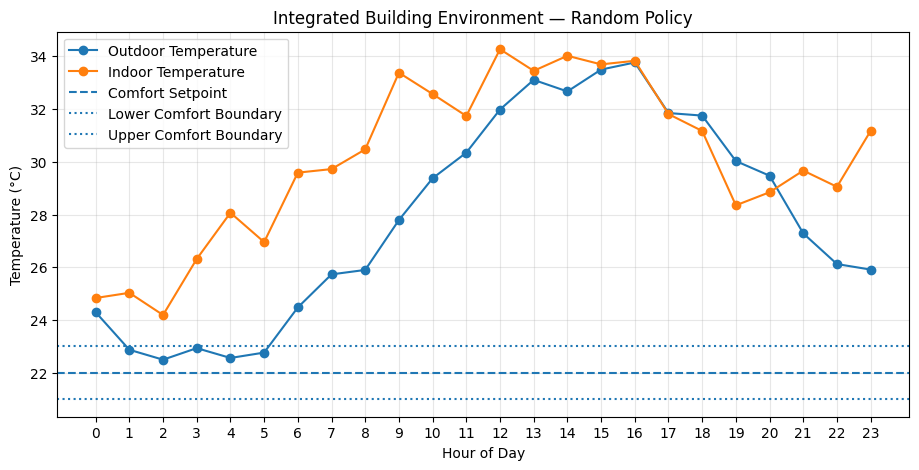

In [52]:
# ============================================================
# Integrated environment trajectory
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    trajectory_df["hour"],
    trajectory_df["outdoor_temp_c"],
    marker="o",
    label="Outdoor Temperature",
)

plt.plot(
    trajectory_df["hour"],
    trajectory_df["indoor_temp_c"],
    marker="o",
    label="Indoor Temperature",
)

plt.axhline(
    22.0,
    linestyle="--",
    label="Comfort Setpoint",
)

plt.axhline(
    21.0,
    linestyle=":",
    label="Lower Comfort Boundary",
)

plt.axhline(
    23.0,
    linestyle=":",
    label="Upper Comfort Boundary",
)

plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.title("Integrated Building Environment — Random Policy")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

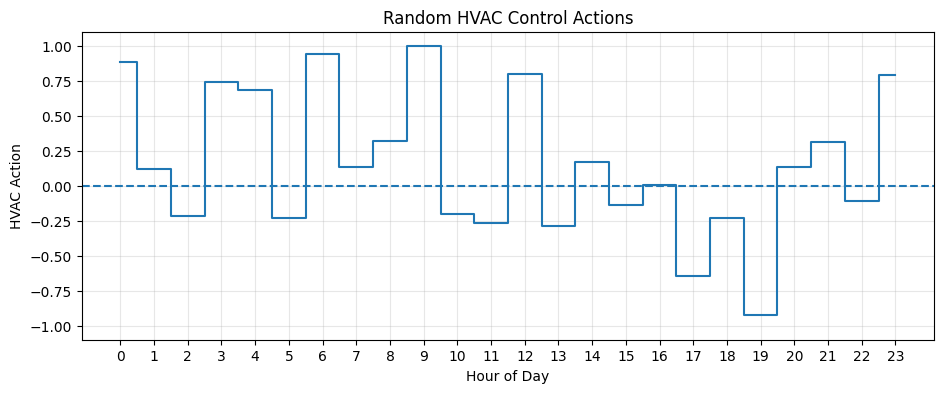

In [53]:
# ============================================================
# HVAC action trajectory
# ============================================================

plt.figure(figsize=(11, 4))

plt.step(
    trajectory_df["hour"],
    trajectory_df["action"],
    where="mid",
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("Hour of Day")
plt.ylabel("HVAC Action")
plt.title("Random HVAC Control Actions")
plt.xticks(range(24))
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.3)

plt.show()

In [54]:
# ============================================================
# Complete episode summary
# ============================================================

episode_summary = {
    "total_reward": trajectory_df["reward"].sum(),
    "total_energy": trajectory_df["energy"].sum(),
    "total_electricity_cost": trajectory_df["electricity_cost"].sum(),
    "mean_indoor_temperature": trajectory_df["indoor_temp_c"].mean(),
    "max_indoor_temperature": trajectory_df["indoor_temp_c"].max(),
    "min_indoor_temperature": trajectory_df["indoor_temp_c"].min(),
    "mean_comfort_deviation": trajectory_df["comfort_deviation"].mean(),
}

for key, value in episode_summary.items():
    print(f"{key:30s}: {value:.4f}")

total_reward                  : -93.5295
total_energy                  : 10.2631
total_electricity_cost        : 6.8843
mean_indoor_temperature       : 30.0910
max_indoor_temperature        : 34.2669
min_indoor_temperature        : 24.1919
mean_comfort_deviation        : 8.0910


In [55]:
# ============================================================
# FINAL ENVIRONMENT ACCEPTANCE TEST
# ============================================================

assert validation_env.action_space.shape == (1,)
assert np.allclose(
    validation_env.action_space.low,
    [-1.0]
)
assert np.allclose(
    validation_env.action_space.high,
    [1.0]
)

assert validation_env.observation_space.shape == (7,)

assert len(trajectory_df) == 24

assert np.isfinite(
    trajectory_df[numeric_columns].to_numpy()
).all()

assert trajectory_df["energy"].ge(0).all()
assert trajectory_df["electricity_cost"].ge(0).all()

print("==============================================")
print("✓ BUILDING ENVIRONMENT VALIDATION PASSED")
print("==============================================")
print("Action dimension:       1")
print("Observation dimension:  7")
print("Episode length:         24 hours")
print("Numerical stability:    PASS")
print("Energy validity:        PASS")
print("Cost validity:          PASS")
print("Gymnasium API:          PASS")

✓ BUILDING ENVIRONMENT VALIDATION PASSED
Action dimension:       1
Observation dimension:  7
Episode length:         24 hours
Numerical stability:    PASS
Energy validity:        PASS
Cost validity:          PASS
Gymnasium API:          PASS
